Saving student-mat.csv to student-mat (4).csv
['.config', 'student-mat.csv', 'student-mat (1).csv', 'student-mat (2).csv', 'drive', 'student-mat (3).csv', 'student-mat (4).csv', 'sample_data']
Shape (rows, columns): (395, 33)

Data types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object
Missing values per column:
No missing values found.
Nu

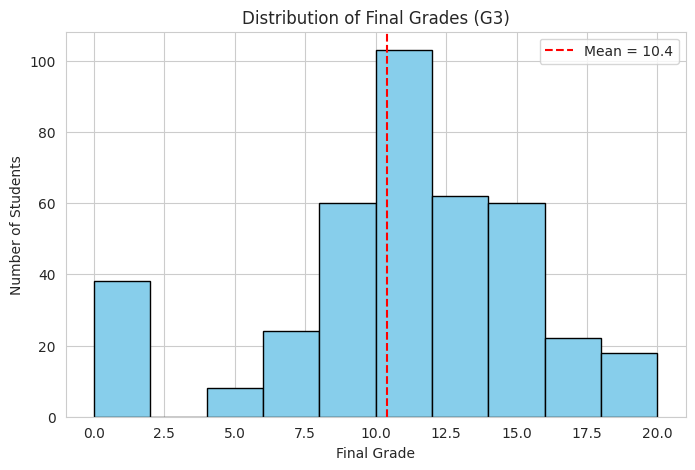

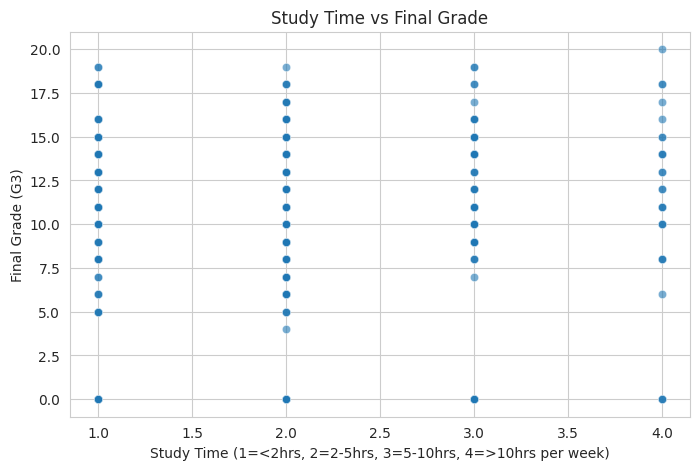

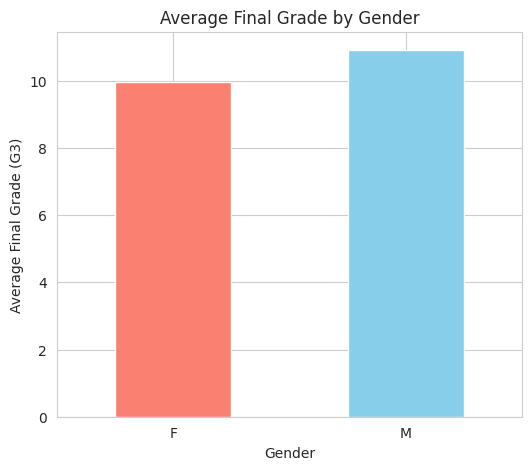

In [7]:
# ===== STEP 1: Import libraries =====
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
from google.colab import files
uploaded = files.upload()

import os
print(os.listdir())

# ===== STEP 2: Load the dataset =====
# NOTE: this CSV uses semicolons (;) not commas, so sep=';' is required
df = pd.read_csv('student-mat.csv', sep=';')
df.head()


# ===== STEP 3: Explore & Clean =====
print('Shape (rows, columns):', df.shape)
print('\nData types:')
print(df.dtypes)

missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

duplicate_count = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_count}')
df = df.drop_duplicates()
print(f'Shape after removing duplicates: {df.shape}')


# ===== STEP 4: Analysis Questions =====

# 4.1 Average final grade
average_g3 = df['G3'].mean()
print(f'Average final grade (G3): {average_g3:.2f} out of 20')

# 4.2 Students scoring above 15
above_15 = df[df['G3'] > 15]
print(f'Number of students who scored above 15: {len(above_15)}')
print(f'That is {len(above_15) / len(df) * 100:.1f}% of all students')

# 4.3 Study time correlation with performance
correlation = df['studytime'].corr(df['G3'])
print(f'Correlation between study time and final grade: {correlation:.3f}')

# 4.4 Which gender performs better
gender_avg = df.groupby('sex')['G3'].mean()
print('Average final grade by gender:')
print(gender_avg)
better_gender = 'Female' if gender_avg['F'] > gender_avg['M'] else 'Male'
print(f'{better_gender} students perform better on average.')


# ===== STEP 5: Visualizations =====

# 5.1 Histogram of grades
plt.figure(figsize=(8, 5))
plt.hist(df['G3'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade')
plt.ylabel('Number of Students')
plt.axvline(df['G3'].mean(), color='red', linestyle='--', label=f"Mean = {df['G3'].mean():.1f}")
plt.legend()
plt.show()

# 5.2 Scatterplot: study time vs grades
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='studytime', y='G3', alpha=0.6)
plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs per week)')
plt.ylabel('Final Grade (G3)')
plt.show()

# 5.3 Bar chart: male vs female average score
plt.figure(figsize=(6, 5))
gender_avg.plot(kind='bar', color=['salmon', 'skyblue'])
plt.title('Average Final Grade by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Final Grade (G3)')
plt.xticks(rotation=0)
plt.show()

- The average final grade (G3) was 10.4 out of 20.
- 40 students scored above 15, about 10.1% of the class.
- The correlation between study time and final grade was 0.098 — a very
  weak relationship. The scatterplot confirms this: points are scattered
  across all study-time levels with no clear upward trend, meaning more
  study time did not guarantee better grades.
- Male students had a slightly higher average grade (10.91) than female
  students (9.97), though the gap is fairly small.
- The histogram shows a rough bell-shaped distribution centered around
  10-12, but with a notable cluster of about 38 students scoring 0 —
  these are likely students who dropped out or did not sit the final exam.
- Overall, the data suggests that factors other than raw study time
  (such as prior grades, attendance, or family support) probably play a
  bigger role in final performance.